In [1]:
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

import seaborn as sns
import os
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("meruvulikith/190k-spam-ham-email-dataset-for-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/shinomi/.cache/kagglehub/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification/versions/1


In [3]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')] # search for the csv files in the download path folder

df = pd.read_csv(os.path.join(path, csv_files[0]))              # join the path folder with the csv file name so we have an absolute path

df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [4]:
def clean_email(text):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)                     # remove special chars
    text = re.sub(r'\s+', ' ', text)                            # remove multiple spaces
    text = text.lower().strip()
    return text

In [5]:
df['text'] = df['text'].apply(clean_email)                      # text cleaning
df['label'] = (df['label'] == 'Spam').astype(int)               # label conversion

df.head()

,label,text
0,1,viiiiiiagraaaa only for the ones that want to ...
1,0,got ice thought look az original message ice o...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...
3,1,start increasing your odds of success live sex...
4,0,author jra date escapenumber escapenumber esca...


In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,          # max word count per vector
    stop_words='english',       # remove common words
    ngram_range=(1,2),          # allow bigrams
    sublinear_tf=True           # normalization
)

X = vectorizer.fit_transform(df['text']).toarray()
y = df['label'].values

print(f"X shape {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training: {len(X_train)}")
print(f"Testing: {len(X_test)}")

X shape (193852, 5000)
Training: 155081
Testing: 38771


In [7]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64,
    shuffle=False
)

In [25]:
class SpamClassifierNN(nn.Module):
    def __init__(self, input=5000, hidden=[2,2], output=1, dr=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input, hidden[0])
        self.bn1 = nn.BatchNorm1d(hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.bn2 = nn.BatchNorm1d(hidden[1])
        self.fc3 = nn.Linear(hidden[1], output)
        self.dropout = nn.Dropout(dr)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
model = SpamClassifierNN(input=X.shape[1]).to(device)

In [27]:
lf = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10

train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = lf(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch: {epoch + 1}, Loss: {avg_loss:.4f}")

Epoch: 1, Loss: 0.0077
Epoch: 2, Loss: 0.0071
Epoch: 3, Loss: 0.0081
Epoch: 4, Loss: 0.0075
Epoch: 5, Loss: 0.0070
Epoch: 6, Loss: 0.0062
Epoch: 7, Loss: 0.0080
Epoch: 8, Loss: 0.0068
Epoch: 9, Loss: 0.0071
Epoch: 10, Loss: 0.0072


In [28]:
def eval_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predicted = (outputs > 0.5).float().view(-1)
            y_batch = y_batch.view(-1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return correct / total

accuracy = eval_model(model, test_loader, device)
print(f"Accuracy {accuracy*100:.2f}%")

Accuracy 98.87%


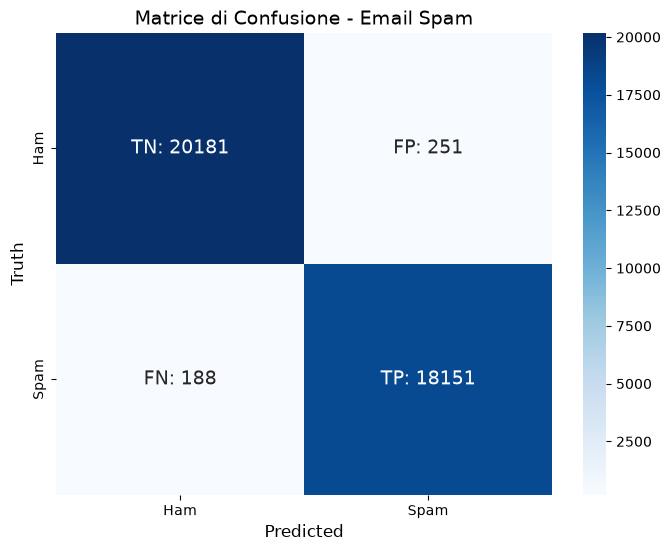

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        predicted = (outputs > 0.5).float().view(-1)
        y_batch = y_batch.view(-1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

tn, fp, fn, tp = cm.ravel()

labels = [
    [f"TN: {tn}", f"FP: {fp}"],
    [f"FN: {fn}", f"TP: {tp}"]
]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm, 
    annot=labels, 
    fmt='', 
    cmap='Blues', 
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
    cbar=True, 
    annot_kws={'size': 14}
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Truth", fontsize=12)
plt.title("Confusion Matrix - Email Spam", fontsize=14)
plt.show()